In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 전처리 작업

In [2]:
df = pd.read_csv(r"C:\Users\rmstn\final_project\Geunsu\data\매출_정보(통합).csv", encoding="cp949")
df

,ta_ymd,cty_rgn_no,admi_cty_no,card_tpbuz_cd,card_tpbuz_nm_1,card_tpbuz_nm_2,hour,sex,age,day,amt,cnt
0,20230101,41131,41131510,D01,소매/유통,가전제품,4,M,5,7,9251291,2
1,20230101,41131,41131510,D01,소매/유통,가전제품,5,F,5,7,62392,4
2,20230101,41131,41131510,D01,소매/유통,가전제품,5,F,6,7,153920,2
3,20230101,41131,41131510,D01,소매/유통,가전제품,5,F,7,7,21515,2
4,20230101,41131,41131510,D01,소매/유통,가전제품,5,M,6,7,544320,4
...,...,...,...,...,...,...,...,...,...,...,...,...
87265536,20251231,41135,41135680,Y04,공공/기업/단체,단체,6,M,7,3,5948,2
87265537,20251231,41135,41135680,Y04,공공/기업/단체,단체,7,F,5,3,779924,3
87265538,20251231,41135,41135680,Y04,공공/기업/단체,단체,7,F,7,3,60508,5
87265539,20251231,41135,41135680,Y04,공공/기업/단체,단체,8,F,6,3,113481,3


## 1.1 전처리 작업(컬럼 확인)

#### 1.1.1 데이터 타입 확인

In [3]:
df.dtypes

ta_ymd             int64
cty_rgn_no         int64
admi_cty_no        int64
card_tpbuz_cd        str
card_tpbuz_nm_1      str
card_tpbuz_nm_2      str
hour               int64
sex                  str
age                int64
day                int64
amt                int64
cnt                int64
dtype: object

#### 1.1.2 컬럼 정제

In [4]:
df['ta_ymd'] = pd.to_datetime(df['ta_ymd'], format='%Y%m%d')
df['cty_rgn_no'] = df['cty_rgn_no'].astype(str)
df['admi_cty_no'] = df['admi_cty_no'].astype(str)

print(df.dtypes)

ta_ymd             datetime64[us]
cty_rgn_no                    str
admi_cty_no                   str
card_tpbuz_cd                 str
card_tpbuz_nm_1               str
card_tpbuz_nm_2               str
hour                        int64
sex                           str
age                         int64
day                         int64
amt                         int64
cnt                         int64
dtype: object


## 1.2 전처리 작업(컬럼별 결측치 및 이상치 확인)

In [5]:
df.isna().sum()

ta_ymd             0
cty_rgn_no         0
admi_cty_no        0
card_tpbuz_cd      0
card_tpbuz_nm_1    0
card_tpbuz_nm_2    0
hour               0
sex                0
age                0
day                0
amt                0
cnt                0
dtype: int64

#### 중복값 확인

In [6]:
key_cols = ['ta_ymd', 'cty_rgn_no', 'admi_cty_no', 'card_tpbuz_cd', 
            'hour', 'sex', 'age', 'day']
key_dup = df.duplicated(subset=key_cols).sum()
print(f"키 컬럼 기준 중복: {key_dup:,}")

키 컬럼 기준 중복: 0


#### 1.2.1 기준년월일

In [7]:
nat_count = df['ta_ymd'].isna().sum()
print(f"변환 실패(NaT) 개수: {nat_count:,}")
print(f"전체 행 개수: {len(df):,}")
print(f"범위: {df['ta_ymd'].min()} ~ {df['ta_ymd'].max()}")

변환 실패(NaT) 개수: 0
전체 행 개수: 87,265,541
범위: 2023-01-01 00:00:00 ~ 2025-12-31 00:00:00


#### 1.2.2 시군구코드

In [8]:
col = df['cty_rgn_no'].astype(str)

print(f"5자리 아닌 값: {len(df[col.str.len() != 5])}건")
print(f"NULL 수: {df['cty_rgn_no'].isnull().sum()}건")
print(f"고유 코드 수: {df['cty_rgn_no'].nunique()}개")
df["cty_rgn_no"].value_counts()

5자리 아닌 값: 0건
NULL 수: 0건
고유 코드 수: 3개


cty_rgn_no
41135    46466118
41131    23519797
41133    17279626
Name: count, dtype: int64

#### 1.2.3 행정동코드

In [9]:
col = df['admi_cty_no'].astype(str)

print(f"8자리 아닌 값: {len(df[col.str.len() != 8])}건")
print(f"고유 코드 수: {df['admi_cty_no'].nunique()}개")

8자리 아닌 값: 0건
고유 코드 수: 50개


#### 1.2.4 카드사_업종분류코드

In [10]:
print(f"공백 값: {len(df[df['card_tpbuz_cd'].astype(str).str.strip() == ''])}건")
print(f"고유 코드 수: {df['card_tpbuz_cd'].nunique()}개")

공백 값: 0건
고유 코드 수: 83개


#### 1.2.5 카드사_업종대분류명

In [11]:
print(f"고유 대분류명 수: {df['card_tpbuz_nm_1'].nunique()}개")
print(df['card_tpbuz_nm_1'].value_counts())

고유 대분류명 수: 9개
card_tpbuz_nm_1
음식          33322117
소매/유통       24577749
생활서비스       10099540
의료/건강        9125257
여가/오락        3912907
학문/교육        2314873
미디어/통신       2079771
공공/기업/단체     1604322
공연/전시         229005
Name: count, dtype: int64


#### 1.2.6 카드사_업종중분류명

In [12]:
print(f"공백 값: {len(df[df['card_tpbuz_nm_2'].astype(str).str.strip() == ''])}건")
print(f"고유 중분류명 수: {df['card_tpbuz_nm_2'].nunique()}개")
print(df['card_tpbuz_nm_2'].value_counts().head(20))

공백 값: 0건
고유 중분류명 수: 83개
card_tpbuz_nm_2
종합소매점         7365346
커피/음료         5043758
한식            4760707
제과/제빵/떡/케익    3779794
음/식료품소매       3697174
의약/의료품        3513674
분식            3422523
일반병원          2933898
패스트푸드         2767467
의복/의류         2718954
연료판매          2479244
고기요리          2138581
일식/수산물        2049049
닭/오리요리        2028881
별식/퓨전요리       2009253
미용서비스         1952030
취미/오락         1789236
중식            1706836
차량관리/서비스      1628022
화장품소매         1552786
Name: count, dtype: int64


#### 1.2.7 시간대

In [13]:
valid_codes = list(range(1, 11))
outliers = df[df['hour'].isin(valid_codes) == False]

if not outliers.empty:
    print(f"이상치 발견! 총 {len(outliers)}건")
    print(outliers['hour'].value_counts())
else:
    print("모든 데이터가 정상 범위(1~10) 내에 있습니다.")

모든 데이터가 정상 범위(1~10) 내에 있습니다.


#### 1.2.8 성별

In [14]:
# 1. 기준값 설정 (대문자 M, F)
valid_sex = ['M', 'F']

# 2. 이상치 검증
# str.strip()을 추가하면 'M ' 같은 공백 포함 데이터를 걸러내거나 무시할지 결정할 수 있습니다.
# 여기서는 정확히 'M', 'F'가 아닌 모든 것을 추출합니다.
outliers = df[~df['sex'].isin(valid_sex)]

# 3. 결과 출력
if not outliers.empty:
    print(f"성별 컬럼 이상치 발견! 총 {len(outliers)}건")
    print("-" * 30)
    print("값별 빈도수:")
    print(outliers['sex'].value_counts(dropna=False)) # NaN(결측치) 포함 확인
else:
    print("성별 데이터가 모두 정상 범위('M', 'F') 내에 있습니다.")

성별 데이터가 모두 정상 범위('M', 'F') 내에 있습니다.


#### 1.2.9 연령별

In [15]:
# 1. 정상 범위 설정 (숫자형 1~11)
# range(1, 12)는 1부터 11까지의 숫자를 생성합니다.
valid_age_codes = list(range(1, 12))

# 2. 이상치 검증
# df['age']가 1~11 사이에 포함되지 않는 행을 추출
outliers = df[~df['age'].isin(valid_age_codes)]

# 3. 결과 출력
if not outliers.empty:
    print(f"연령대(age) 컬럼 이상치 발견! 총 {len(outliers)}건")
    print("-" * 30)
    print("잘못된 값 목록 및 빈도수:")
    print(outliers['age'].value_counts(dropna=False).sort_index())
else:
    print("모든 연령대 데이터가 정상 범위(1~11) 내에 있습니다.")

모든 연령대 데이터가 정상 범위(1~11) 내에 있습니다.


#### 1.2.10 요일

In [16]:
# 1. 정상 범위 설정 (숫자형 1~11)
# range(1, 12)는 1부터 11까지의 숫자를 생성합니다.
valid_day_codes = list(range(1, 8))

# 2. 이상치 검증
# df['age']가 1~11 사이에 포함되지 않는 행을 추출
outliers = df[~df['day'].isin(valid_day_codes)]

# 3. 결과 출력
if not outliers.empty:
    print(f"요일(day) 컬럼 이상치 발견! 총 {len(outliers)}건")
    print("-" * 30)
    print("잘못된 값 목록 및 빈도수:")
    print(outliers['day'].value_counts(dropna=False).sort_index())
else:
    print("모든 요일 데이터가 정상 범위(1~7) 내에 있습니다.")

모든 요일 데이터가 정상 범위(1~7) 내에 있습니다.


#### 1.2.11 매출금액

In [17]:
pd.options.display.float_format = '{:,.2f}'.format
df["amt"].describe()

count       87,265,541.00
mean         3,363,578.84
std         63,571,884.73
min                  0.00
25%             28,249.00
50%             88,768.00
75%            300,643.00
max     23,218,483,247.00
Name: amt, dtype: float64

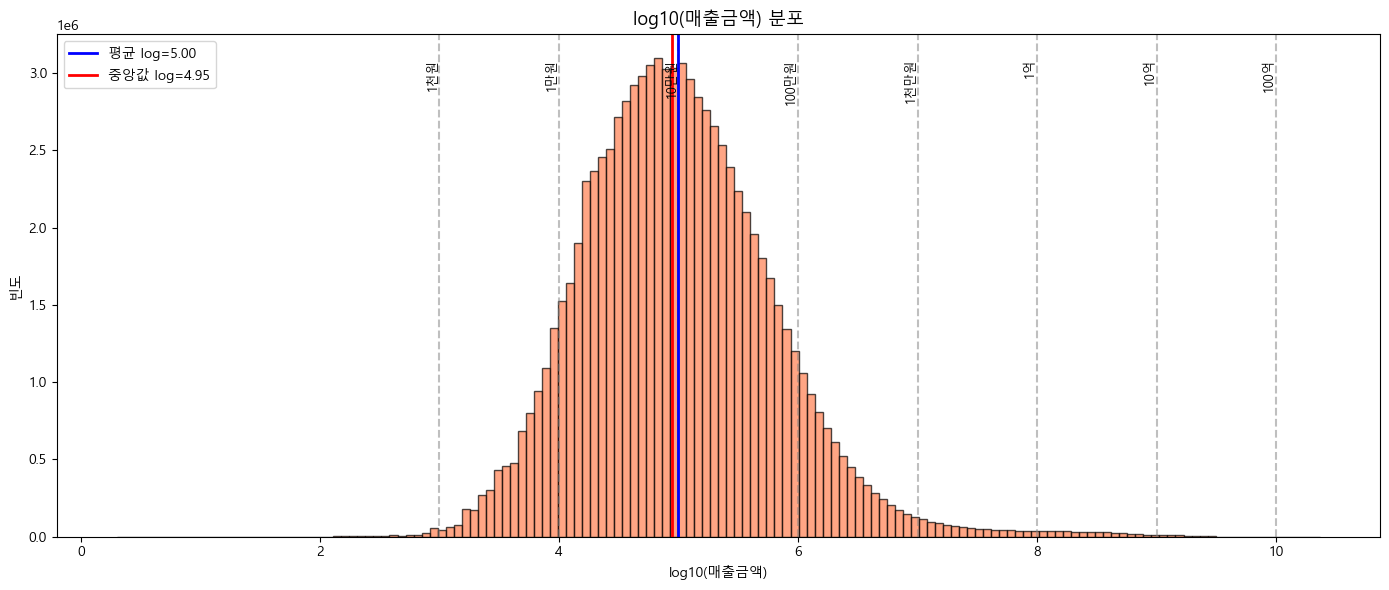

In [19]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 로그 변환 (0원 제외)
amt = df.loc[df['amt'] > 0, 'amt']
log_amt = np.log10(amt)

# 시각화
fig, ax = plt.subplots(figsize=(14, 6))
ax.hist(log_amt, bins=150, color='coral', edgecolor='black', alpha=0.7)

# 주요 금액 경계선
for val, label in [(3, '1천원'), (4, '1만원'), (5, '10만원'), (6, '100만원'),
                    (7, '1천만원'), (8, '1억'), (9, '10억'), (10, '100억')]:
    ax.axvline(val, color='gray', linestyle='--', alpha=0.5)
    ax.text(val, ax.get_ylim()[1]*0.95, label, rotation=90, 
            va='top', ha='right', fontsize=9)

# 평균·중앙값
ax.axvline(log_amt.mean(), color='blue', linewidth=2, label=f'평균 log={log_amt.mean():.2f}')
ax.axvline(log_amt.median(), color='red', linewidth=2, label=f'중앙값 log={log_amt.median():.2f}')

ax.set_title('log10(매출금액) 분포', fontsize=13)
ax.set_xlabel('log10(매출금액)')
ax.set_ylabel('빈도')
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
# 제거 전 확인
print(f"제거 전 총 행 수: {len(df):,}")
print(f"amt = 0 인 행 수: {(df['amt'] == 0).sum():,}")
print(f"cnt = 0 인 행 수: {(df['cnt'] == 0).sum():,}")
print(f"amt = 0 또는 cnt = 0 인 행 수: {((df['amt'] == 0) | (df['cnt'] == 0)).sum():,}")

# amt가 0이거나 cnt가 0인 행 제거
df = df[(df['amt'] != 0) & (df['cnt'] != 0)].reset_index(drop=True)

# 제거 후 확인
print(f"\n제거 후 총 행 수: {len(df):,}")
print(f"amt 최솟값: {df['amt'].min():,}")
print(f"cnt 최솟값: {df['cnt'].min():,}")

제거 전 총 행 수: 87,265,541
amt = 0 인 행 수: 2,393
cnt = 0 인 행 수: 1,515
amt = 0 또는 cnt = 0 인 행 수: 2,413

제거 후 총 행 수: 87,263,128
amt 최솟값: 2
cnt 최솟값: 1


#### 1.2.12 매출건수

In [21]:
df['cnt'].describe()
df['cnt'].quantile([0.5, 0.9, 0.95, 0.99, 0.999])

0.50        4.00
0.90       34.00
0.95       70.00
0.99      357.00
1.00   15,701.00
Name: cnt, dtype: float64

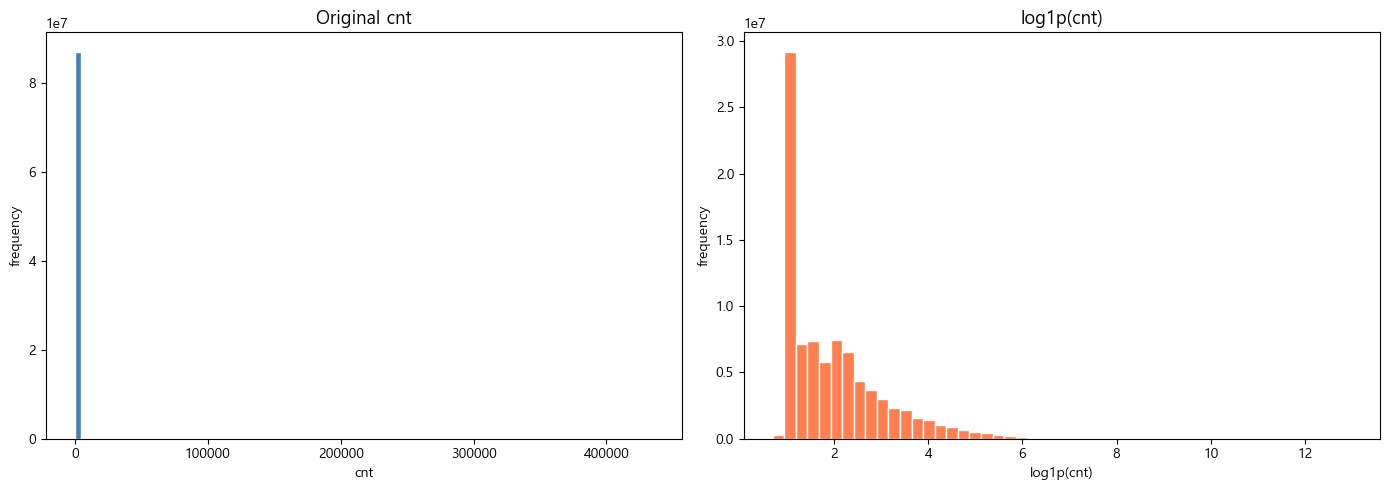

=== 로그 변환 후 통계 ===
count   87,263,128.00
mean             2.04
std              1.16
min              0.69
25%              1.10
50%              1.61
75%              2.48
max             12.98
Name: cnt, dtype: float64

=== 분위수 비교 ===
       original  log1p
0.50       4.00   1.61
0.90      34.00   3.56
0.95      70.00   4.26
0.99     357.00   5.88
1.00 435,198.00  12.98


In [22]:
import numpy as np
import matplotlib.pyplot as plt

# 로그 변환
cnt_log = np.log1p(df['cnt'])

# 원본 vs 로그변환 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 원본
axes[0].hist(df['cnt'], bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Original cnt', fontsize=13)
axes[0].set_xlabel('cnt')
axes[0].set_ylabel('frequency')

# 로그 변환 후
axes[1].hist(cnt_log, bins=50, color='coral', edgecolor='white')
axes[1].set_title('log1p(cnt)', fontsize=13)
axes[1].set_xlabel('log1p(cnt)')
axes[1].set_ylabel('frequency')

plt.tight_layout()
plt.show()

# 통계값도 같이 확인
print("=== 로그 변환 후 통계 ===")
print(cnt_log.describe())
print("\n=== 분위수 비교 ===")
print(pd.DataFrame({
    'original': df['cnt'].quantile([0.5, 0.9, 0.95, 0.99, 1.0]),
    'log1p': cnt_log.quantile([0.5, 0.9, 0.95, 0.99, 1.0])
}))